In [64]:
import getpass
import os

def _set_env(var:str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [65]:
from langchain_community.document_loaders import PyPDFLoader

In [66]:
file_path = "./../dataset/SPRi AI Brief 4월호_260401.pdf"
loader = PyPDFLoader(file_path)

pages = loader.load()
print(len(pages))

29


In [67]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [68]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=  1000,
    chunk_overlap = 200,
    add_start_index = True
)

In [69]:
docs = text_splitter.split_documents(pages)

print(f'총 {len(docs)}개 만큼의 문서로 청킹되었습니다.')
print([len(doc.page_content) for doc in docs[:10]])

# 총 57개 만큼의 문서로 청킹되었습니다.
# [3, 968, 999, 518, 126, 979, 886, 341, 973, 833]

총 57개 만큼의 문서로 청킹되었습니다.
[3, 968, 999, 518, 126, 979, 886, 341, 973, 833]


In [70]:
for doc in docs[:3]:
    print(doc.metadata)
    print(doc.page_content[:500])
    print("-" * 30)

{'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-04-01T07:54:49+09:00', 'author': '', 'moddate': '2026-04-01T07:54:49+09:00', 'title': 'SPRi AI Brief 4ìłﬂíŸ¸_260401.hwp', 'source': './../dataset/SPRi AI Brief 4월호_260401.pdf', 'total_pages': 29, 'page': 0, 'page_label': '1', 'start_index': 0}
월호4
------------------------------
{'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-04-01T07:54:49+09:00', 'author': '', 'moddate': '2026-04-01T07:54:49+09:00', 'title': 'SPRi AI Brief 4ìłﬂíŸ¸_260401.hwp', 'source': './../dataset/SPRi AI Brief 4월호_260401.pdf', 'total_pages': 29, 'page': 1, 'page_label': '2', 'start_index': 0}
Ⅰ 년 월호2026 1 Ⅰ
월간 모델현황AI∙ 년 월 월간 모델 현황 2026 3 AI 1
정책･법제
∙중국 과학기술의 자립자강 강조한 제 차 개년 규획 발표                                      , 15 5 3
∙ 에이전틱 의 개념과 도입 현황을 다룬 보고서 발표 OECD, AI    4
∙미국 국립연구소들 제네시스 미션 수행을 위해 인프라 확대 추진, ‘ ’ AI  5
∙미국 뉴욕주 챗봇의 전문직 사칭 금지 법안 추진, AI  6
미국 법원 앤트로픽을 공급망 위험으로 지정한 국방부 조치에 제동, ∙  7
∙미국 트럼프 대통

In [71]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai import OpenAIEmbeddings

In [72]:
semantic_splitter = SemanticChunker(OpenAIEmbeddings())
semantic_docs = semantic_splitter.split_documents(pages)

print(f'총 {len(semantic_docs)}개 만큼의 문서로 청킹되었습니다.')
print([len(doc.page_content) for doc in semantic_docs[:10]])

# 총 32개 만큼의 문서로 청킹되었습니다.
# [3, 968, 1078, 254, 126, 1855, 1804, 1918, 1687, 1785]

총 32개 만큼의 문서로 청킹되었습니다.
[3, 968, 1078, 254, 126, 1855, 1804, 1918, 1687, 1785]


In [73]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

#large -> 고품질(정확도 높음), 벡터차원 3072,
# small -> 벡터차원: 1536 서로 임베딩 차원이 달라 호환이 안됨.

embeddings = OpenAIEmbeddings(model = 'text-embedding-3-large')
vectorstore = Chroma.from_documents(
    documents= docs,
    embedding = embeddings,
    persist_directory= "./chroma_db"
)

In [74]:
query = "트럼프가 제시한 AI입법 프레임워크를 정리한다면?"
results = vectorstore.similarity_search(query, k=1)
print(results[0].page_content)

# SPRi AI Brief
#  2026년  4월호
# 8
# 미국 트럼프 대통령 국가 입법 프레임워크 발표, AI 
# KEY Contents
# 미국 트럼프 행정부가 아동 보호 지식재산권 존중 표현의 자유 보장 혁신 촉진 등 개 핵심 , , , 6
# 목표를 담은 국가 입법 프레임워크 를 발표하고 연방 차원의 통일된 정책 수립을 촉구‘AI ’ AI 
# 트럼프 행정부는 각 주의 상이한 규제가 미국의 혁신 역량을 저해할 수 있다고 판단하고AI , 
# 연방법을 통해 주 단위의 과도한 규제를 무효화함으로써 일관된 국가 기준 확립을 추진   
# 국가 입법 프레임워크 개 핵심 목표와 입법 과제 제시AI , 6
#  미국 트럼프 대통령이 년 월 일 글로벌 주도권 확보와 경제적 번영을 위한2026 3 20 AI 개 핵심  6
# 목표를 포괄하는 국가 입법 프레임워크 를 발표하고 의회의 입법 협력을 촉구   ‘ AI ’
#  아동 보호와 부모 권한 강화 플랫폼에 미성년자의 성착취 및 자해 위험을 줄일 수 있는 안전 기능을 ( ) AI 
# 의무화하고 부모가 자녀의 디지털 환경을 직접 관리할 수 있는 실질적 도구를 제공하는 입법 조치 필요, 
#  지역사회 보호 인프라 구축을 위한 연방 허가 절차를 간소화하여 성장을 도모하되 데이터센터 ( ) AI , AI 
# 건설에 따른 전기 요금 인상의 부담이 일반 소비자에게 전가되지 않도록 방지 
#  지식재산권 보호와 창작자 지원 의 저작물 학습 합법성 여부는 법원의 판단에 맡기고 권리자들이 ( ) AI , 
# 제공 기업과 집단적으로 보상을 협상할 수 있는 라이선스 체계와 무단 디지털 복제 방지책을 마련AI 
#  표현의 자유 보호 정부가 정파적 또는 이념적 목적으로 플랫폼의 콘텐츠를 강제로 차단하거나 변경할 ( ) AI 
# 수 없도록 하고 를 활용한 합법적 정치 표현의 검열을 막을 실질적 구제 수단을 마련, AI
#  혁신 촉진과 미국의 주도권 확보 응용 분야에 규제 샌드박스를 도입하고 연방 데이터셋을 학습( AI ) AI AI

SPRi AI Brief
 2026년  4월호
8
미국 트럼프 대통령 국가 입법 프레임워크 발표, AI 
KEY Contents
미국 트럼프 행정부가 아동 보호 지식재산권 존중 표현의 자유 보장 혁신 촉진 등 개 핵심 , , , 6
목표를 담은 국가 입법 프레임워크 를 발표하고 연방 차원의 통일된 정책 수립을 촉구‘AI ’ AI 
트럼프 행정부는 각 주의 상이한 규제가 미국의 혁신 역량을 저해할 수 있다고 판단하고AI , 
연방법을 통해 주 단위의 과도한 규제를 무효화함으로써 일관된 국가 기준 확립을 추진   
국가 입법 프레임워크 개 핵심 목표와 입법 과제 제시AI , 6
 미국 트럼프 대통령이 년 월 일 글로벌 주도권 확보와 경제적 번영을 위한2026 3 20 AI 개 핵심  6
목표를 포괄하는 국가 입법 프레임워크 를 발표하고 의회의 입법 협력을 촉구   ‘ AI ’
 아동 보호와 부모 권한 강화 플랫폼에 미성년자의 성착취 및 자해 위험을 줄일 수 있는 안전 기능을 ( ) AI 
의무화하고 부모가 자녀의 디지털 환경을 직접 관리할 수 있는 실질적 도구를 제공하는 입법 조치 필요, 
 지역사회 보호 인프라 구축을 위한 연방 허가 절차를 간소화하여 성장을 도모하되 데이터센터 ( ) AI , AI 
건설에 따른 전기 요금 인상의 부담이 일반 소비자에게 전가되지 않도록 방지 
 지식재산권 보호와 창작자 지원 의 저작물 학습 합법성 여부는 법원의 판단에 맡기고 권리자들이 ( ) AI , 
제공 기업과 집단적으로 보상을 협상할 수 있는 라이선스 체계와 무단 디지털 복제 방지책을 마련AI 
 표현의 자유 보호 정부가 정파적 또는 이념적 목적으로 플랫폼의 콘텐츠를 강제로 차단하거나 변경할 ( ) AI 
수 없도록 하고 를 활용한 합법적 정치 표현의 검열을 막을 실질적 구제 수단을 마련, AI
 혁신 촉진과 미국의 주도권 확보 응용 분야에 규제 샌드박스를 도입하고 연방 데이터셋을 학습( AI ) AI AI


In [75]:
vector_retriever = vectorstore.as_retriever(search_kwargs = {"k":1})
vector_result = vector_retriever.invoke(query)
print(vector_result[0].page_content)


SPRi AI Brief
 2026년  4월호
8
미국 트럼프 대통령 국가 입법 프레임워크 발표, AI 
KEY Contents
미국 트럼프 행정부가 아동 보호 지식재산권 존중 표현의 자유 보장 혁신 촉진 등 개 핵심 , , , 6
목표를 담은 국가 입법 프레임워크 를 발표하고 연방 차원의 통일된 정책 수립을 촉구‘AI ’ AI 
트럼프 행정부는 각 주의 상이한 규제가 미국의 혁신 역량을 저해할 수 있다고 판단하고AI , 
연방법을 통해 주 단위의 과도한 규제를 무효화함으로써 일관된 국가 기준 확립을 추진   
국가 입법 프레임워크 개 핵심 목표와 입법 과제 제시AI , 6
 미국 트럼프 대통령이 년 월 일 글로벌 주도권 확보와 경제적 번영을 위한2026 3 20 AI 개 핵심  6
목표를 포괄하는 국가 입법 프레임워크 를 발표하고 의회의 입법 협력을 촉구   ‘ AI ’
 아동 보호와 부모 권한 강화 플랫폼에 미성년자의 성착취 및 자해 위험을 줄일 수 있는 안전 기능을 ( ) AI 
의무화하고 부모가 자녀의 디지털 환경을 직접 관리할 수 있는 실질적 도구를 제공하는 입법 조치 필요, 
 지역사회 보호 인프라 구축을 위한 연방 허가 절차를 간소화하여 성장을 도모하되 데이터센터 ( ) AI , AI 
건설에 따른 전기 요금 인상의 부담이 일반 소비자에게 전가되지 않도록 방지 
 지식재산권 보호와 창작자 지원 의 저작물 학습 합법성 여부는 법원의 판단에 맡기고 권리자들이 ( ) AI , 
제공 기업과 집단적으로 보상을 협상할 수 있는 라이선스 체계와 무단 디지털 복제 방지책을 마련AI 
 표현의 자유 보호 정부가 정파적 또는 이념적 목적으로 플랫폼의 콘텐츠를 강제로 차단하거나 변경할 ( ) AI 
수 없도록 하고 를 활용한 합법적 정치 표현의 검열을 막을 실질적 구제 수단을 마련, AI
 혁신 촉진과 미국의 주도권 확보 응용 분야에 규제 샌드박스를 도입하고 연방 데이터셋을 학습( AI ) AI AI


In [76]:
from langchain_community.retrievers import BM25Retriever

In [77]:
bm25_retriever = BM25Retriever.from_documents(docs)
bm25_retriever.k = 1
bm25_result = bm25_retriever.invoke(query)
print(bm25_result[0].page_content)

# 1 정책･법제
# 2 기업･산업
# 3 기술･연구
# 4 인력･교육
# 11
# 시트리니 리서치 년 글로벌 인텔리전스 위기 시나리오 공개, ‘2028 ’ 
# KEY Contents
# 시트리니 리서치의 년 글로벌 인텔리전스 위기 시나리오에 따르면 기반 생산성 ‘2028 ’ AI 
# 혁명의 충격이 향후 소비 기반과 신용 주택담보 시장 전반으로 연쇄 전파될 전망 , 
# 가상 시나리오 공개 직후 우버 마스터카드 등 시나리오에 언급된 기업들의 주가가 급락한 , 
# 사건은 에이전트 확산에 따른 구조적 재편에 대한 시장의 우려 수준을 시사AI 
# 에이전트의 광범위한 채택으로 일자리와 산업 전반에 구조적 충격 예측AI 
#  미국의 거시경제 분석 기관 시트리니 리서치 가 년 월 일 시점을 가정한(Citrini Research) 2028 6 30  
# 가상의 거시경제 시나리오를 제시한 년 글로벌 인텔리전스 위기 보고서를 발표 ‘2028 ’ 
#  해당 시나리오에 따르면 년 월 지수가 선을 돌파한 이후 에이전트 기반의 2026 10 S&P500 8,000 AI 
# 생산성 급등으로 명목 는 고성장을 지속했으나 같은 기간 실질 임금은 역성장GDP , 
#  도입으로 감원된 사무직 노동자들이 저임금 서비스직으로 이동하면서 해당 직군 임금까지 하방 압박을 AI 
# 받으며 소비 지출이 의 를 차지하는 미국 경제의 고스트 , GDP 70% ' GDP * 현상 심화' 
#   *  장부상 로 잡히지만 가계 소득이나 소비로 순환되지 않는 자본 집약형 생산성GDP AI·
#  에이전트가 소비자 의사결정을 대신하는 한편 카드 중개 수수료를 우회하기 위해 암호화폐를 사용하면서AI ,  
# 카드 여행 보험 부동산 결제 등 중개경제 전반이 해체, , , , 
#  시트리니 리서치는 소프트웨어 분야에 국한된 것으로 여겨졌던 충격이 사모 신용과 주택담보 AI 
# 시장으로 연쇄 전파되고 정책 대응이 지연되며 사회적 긴장이 고조될 것으로 예측 , 
#  에이전틱 코딩 도구의 급속한 발전으로 기업 내부에서 기능을 수 주 안에 복제할 수 있게 되면서 SaaS

1 정책･법제
2 기업･산업
3 기술･연구
4 인력･교육
11
시트리니 리서치 년 글로벌 인텔리전스 위기 시나리오 공개, ‘2028 ’ 
KEY Contents
시트리니 리서치의 년 글로벌 인텔리전스 위기 시나리오에 따르면 기반 생산성 ‘2028 ’ AI 
혁명의 충격이 향후 소비 기반과 신용 주택담보 시장 전반으로 연쇄 전파될 전망 , 
가상 시나리오 공개 직후 우버 마스터카드 등 시나리오에 언급된 기업들의 주가가 급락한 , 
사건은 에이전트 확산에 따른 구조적 재편에 대한 시장의 우려 수준을 시사AI 
에이전트의 광범위한 채택으로 일자리와 산업 전반에 구조적 충격 예측AI 
 미국의 거시경제 분석 기관 시트리니 리서치 가 년 월 일 시점을 가정한(Citrini Research) 2028 6 30  
가상의 거시경제 시나리오를 제시한 년 글로벌 인텔리전스 위기 보고서를 발표 ‘2028 ’ 
 해당 시나리오에 따르면 년 월 지수가 선을 돌파한 이후 에이전트 기반의 2026 10 S&P500 8,000 AI 
생산성 급등으로 명목 는 고성장을 지속했으나 같은 기간 실질 임금은 역성장GDP , 
 도입으로 감원된 사무직 노동자들이 저임금 서비스직으로 이동하면서 해당 직군 임금까지 하방 압박을 AI 
받으며 소비 지출이 의 를 차지하는 미국 경제의 고스트 , GDP 70% ' GDP * 현상 심화' 
  *  장부상 로 잡히지만 가계 소득이나 소비로 순환되지 않는 자본 집약형 생산성GDP AI·
 에이전트가 소비자 의사결정을 대신하는 한편 카드 중개 수수료를 우회하기 위해 암호화폐를 사용하면서AI ,  
카드 여행 보험 부동산 결제 등 중개경제 전반이 해체, , , , 
 시트리니 리서치는 소프트웨어 분야에 국한된 것으로 여겨졌던 충격이 사모 신용과 주택담보 AI 
시장으로 연쇄 전파되고 정책 대응이 지연되며 사회적 긴장이 고조될 것으로 예측 , 
 에이전틱 코딩 도구의 급속한 발전으로 기업 내부에서 기능을 수 주 안에 복제할 수 있게 되면서 SaaS


In [78]:
from langchain_classic.retrievers import EnsembleRetriever

ensemble_retriever = EnsembleRetriever(
    retrievers= [bm25_retriever, vector_retriever],
    weights = [0.7,0.3]
)

query = '터보퀀트 기술'
ensemble_result = ensemble_retriever.invoke(query)
bm25_result = bm25_retriever.invoke(query)
vector_result = vector_retriever.invoke(query)

print("[Ensemble Retriever]")
for doc in ensemble_result:
    print(doc.page_content)
    print()

print("[BM25 Retriever]")
for doc in bm25_result:
    print(doc.page_content)
    print()

print("[Vector Retriever]")
for doc in vector_result:
    print(doc.page_content)
    print()


#     [Ensemble Retriever]
# SPRi AI Brief
#  2026년  4월호
# 20
# 구글 메모리 사용량을 획기적으로 줄이는 터보퀀트 기술 개발, AI ‘ ’ 
# KEY Contents
# 구글 리서치가 대규모 압축을 통해 모델의 메모리 병목 현상을 해결하여 의 효율성을 AI AI
# 극대화하는 양자화 알고리즘 터보퀀트 기술을 개발했다고 발표‘ ’ 
# 터보퀀트를 적용한 실험 결과 고속 임시 메모리 캐시 를 기존 대비 배 이상 압축하면서 모델의, (KV ) 6  
# 정확도는 그대로 유지되었으며 환경에서 최대 배 빠른 연산 속도를 기록, H100 GPU 8
# 터보퀀트 정확도 손실 없이 메모리 사용량을 분의 로 절감, AI 6 1
#  구글이 년 월 일 모델의 메모리 사용량을 획기적으로 줄이면서도 성능을 그대로 2026 3 24 AI 
# 유지할 수 있는 차세대 양자화 알고리즘 터보퀀트 를 발표 ‘ (TurboQuant)’
#  이 기술은 추론 시 이 이전 토큰의 문맥 정보를 활용하기 위해 저장하는 캐시LLM ‘KV (Key-Value 
# 를 기존 대비 배 이상 압축하면서도 모델의 정확도를 완벽하게 유지Cache)’ 6
#   * 이 이전 토큰들의 정보를 저장해 반복 계산을 줄여 다음 토큰을 빠르게 생성하는 고속 임시 메모리 구조LLM
#  모델은 이미지의 특징이나 단어의 의미를 고차원 벡터 라는 수치 집합으로 이해하는데 모델 성능이AI ‘ ’ ,  
# 발전할수록 벡터의 차원이 높아지며 데이터가 많이 축적되어 캐시의 병목 현상이 발생KV 
#  데이터 압축 효율이 낮은 기존 양자화 기술과 달리 터보퀀트는 기존의 직교좌표가 아닌 크기와‘  방향 ’ 
# 중심의 극좌표로 변환하는 기법으로 효율적인 압축을 지원함으로써 병목 현상을 해결하며 양자화 과정 ,
# 의 정보 손실을 최소화하는 방식으로 정확도를 유지
#  연구진의 실험 결과 터보퀀트는 모델 기준으로 캐시를 기존, ‘Llama-3.1-8B-Instruct’ KV  비트 16
# 에서 채널당 약 비트 수준까지 줄이면서도 성능 저하 없이 동일한 결과를 유지 3~3.5

# 기술･연구
# Ⅰ 년 월호2026 4 Ⅰ

# [BM25 Retriever]
# SPRi AI Brief
#  2026년  4월호
# 20
# 구글 메모리 사용량을 획기적으로 줄이는 터보퀀트 기술 개발, AI ‘ ’ 
# KEY Contents
# 구글 리서치가 대규모 압축을 통해 모델의 메모리 병목 현상을 해결하여 의 효율성을 AI AI
# 극대화하는 양자화 알고리즘 터보퀀트 기술을 개발했다고 발표‘ ’ 
# 터보퀀트를 적용한 실험 결과 고속 임시 메모리 캐시 를 기존 대비 배 이상 압축하면서 모델의, (KV ) 6  
# 정확도는 그대로 유지되었으며 환경에서 최대 배 빠른 연산 속도를 기록, H100 GPU 8
# 터보퀀트 정확도 손실 없이 메모리 사용량을 분의 로 절감, AI 6 1
#  구글이 년 월 일 모델의 메모리 사용량을 획기적으로 줄이면서도 성능을 그대로 2026 3 24 AI 
# 유지할 수 있는 차세대 양자화 알고리즘 터보퀀트 를 발표 ‘ (TurboQuant)’
#  이 기술은 추론 시 이 이전 토큰의 문맥 정보를 활용하기 위해 저장하는 캐시LLM ‘KV (Key-Value 
# 를 기존 대비 배 이상 압축하면서도 모델의 정확도를 완벽하게 유지Cache)’ 6
#   * 이 이전 토큰들의 정보를 저장해 반복 계산을 줄여 다음 토큰을 빠르게 생성하는 고속 임시 메모리 구조LLM
#  모델은 이미지의 특징이나 단어의 의미를 고차원 벡터 라는 수치 집합으로 이해하는데 모델 성능이AI ‘ ’ ,  
# 발전할수록 벡터의 차원이 높아지며 데이터가 많이 축적되어 캐시의 병목 현상이 발생KV 
#  데이터 압축 효율이 낮은 기존 양자화 기술과 달리 터보퀀트는 기존의 직교좌표가 아닌 크기와‘  방향 ’ 
# 중심의 극좌표로 변환하는 기법으로 효율적인 압축을 지원함으로써 병목 현상을 해결하며 양자화 과정 ,
# 의 정보 손실을 최소화하는 방식으로 정확도를 유지
#  연구진의 실험 결과 터보퀀트는 모델 기준으로 캐시를 기존, ‘Llama-3.1-8B-Instruct’ KV  비트 16
# 에서 채널당 약 비트 수준까지 줄이면서도 성능 저하 없이 동일한 결과를 유지 3~3.5

# [Vector Retriever]
# 기술･연구
# Ⅰ 년 월호2026 4 Ⅰ

[Ensemble Retriever]
SPRi AI Brief
 2026년  4월호
20
구글 메모리 사용량을 획기적으로 줄이는 터보퀀트 기술 개발, AI ‘ ’ 
KEY Contents
구글 리서치가 대규모 압축을 통해 모델의 메모리 병목 현상을 해결하여 의 효율성을 AI AI
극대화하는 양자화 알고리즘 터보퀀트 기술을 개발했다고 발표‘ ’ 
터보퀀트를 적용한 실험 결과 고속 임시 메모리 캐시 를 기존 대비 배 이상 압축하면서 모델의, (KV ) 6  
정확도는 그대로 유지되었으며 환경에서 최대 배 빠른 연산 속도를 기록, H100 GPU 8
터보퀀트 정확도 손실 없이 메모리 사용량을 분의 로 절감, AI 6 1
 구글이 년 월 일 모델의 메모리 사용량을 획기적으로 줄이면서도 성능을 그대로 2026 3 24 AI 
유지할 수 있는 차세대 양자화 알고리즘 터보퀀트 를 발표 ‘ (TurboQuant)’
 이 기술은 추론 시 이 이전 토큰의 문맥 정보를 활용하기 위해 저장하는 캐시LLM ‘KV (Key-Value 
를 기존 대비 배 이상 압축하면서도 모델의 정확도를 완벽하게 유지Cache)’ 6
  * 이 이전 토큰들의 정보를 저장해 반복 계산을 줄여 다음 토큰을 빠르게 생성하는 고속 임시 메모리 구조LLM
 모델은 이미지의 특징이나 단어의 의미를 고차원 벡터 라는 수치 집합으로 이해하는데 모델 성능이AI ‘ ’ ,  
발전할수록 벡터의 차원이 높아지며 데이터가 많이 축적되어 캐시의 병목 현상이 발생KV 
 데이터 압축 효율이 낮은 기존 양자화 기술과 달리 터보퀀트는 기존의 직교좌표가 아닌 크기와‘  방향 ’ 
중심의 극좌표로 변환하는 기법으로 효율적인 압축을 지원함으로써 병목 현상을 해결하며 양자화 과정 ,
의 정보 손실을 최소화하는 방식으로 정확도를 유지
 연구진의 실험 결과 터보퀀트는 모델 기준으로 캐시를 기존, ‘Llama-3.1-8B-Instruct’ KV  비트 16
에서 채널당 약 비트 수준까지 줄이면서도 성능 저하 없이 동일한 결과를 유지 

In [79]:
from langgraph.graph import StateGraph, MessagesState, START, END
    
class State(MessagesState):
    context: str

In [80]:
graph_builder = StateGraph(State)

In [81]:
def retriever(state:State):
    print('-------Retriever----------')
    query = state['messages'][-1].content
    retrieved_docs = ensemble_retriever.invoke(query)
    context = retrieved_docs[0].page_content
    print('[CONTEXT]\n', context)
    return {"context": context}

In [82]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model = 'gpt-5.4-2026-03-05', temperature=0)
prompt = ChatPromptTemplate(
    [
        (
            "system"
            """당신은 검색된 문서를 바탕으로 질문에 답하는 도우미입니다.
            반드시 한국어로 답변하세요
            모르는 내용은 억지로 추측하지 말고 모른다고 답하세요
            [검색문맥]
            {context}"""
        ),("human", "{question}")
    ]
)

In [83]:
def answer(state:State):
    print("--------ANSWER-----------")
    query = state['messages'][-1].content
    context = state['context']
    chain = prompt | llm
    response = chain.invoke(
        {
            "context": context,
            "question":query
        }
    )
    return {"messages": [response]}

In [84]:
graph_builder.add_node("retriever", retriever)
graph_builder.add_node("answer", answer)
graph_builder.add_edge(START, "retriever")
graph_builder.add_edge("retriever", "answer")
graph_builder.add_edge("answer", END)


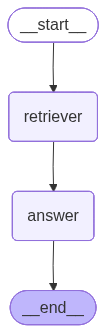

In [85]:
graph = graph_builder.compile()
graph

In [88]:
response = graph.invoke({"messages": "터보퀀트 요약해줘"})

for mes in response['messages']:
    mes.pretty_print()

-------Retriever----------
[CONTEXT]
 SPRi AI Brief
 2026년  4월호
20
구글 메모리 사용량을 획기적으로 줄이는 터보퀀트 기술 개발, AI ‘ ’ 
KEY Contents
구글 리서치가 대규모 압축을 통해 모델의 메모리 병목 현상을 해결하여 의 효율성을 AI AI
극대화하는 양자화 알고리즘 터보퀀트 기술을 개발했다고 발표‘ ’ 
터보퀀트를 적용한 실험 결과 고속 임시 메모리 캐시 를 기존 대비 배 이상 압축하면서 모델의, (KV ) 6  
정확도는 그대로 유지되었으며 환경에서 최대 배 빠른 연산 속도를 기록, H100 GPU 8
터보퀀트 정확도 손실 없이 메모리 사용량을 분의 로 절감, AI 6 1
 구글이 년 월 일 모델의 메모리 사용량을 획기적으로 줄이면서도 성능을 그대로 2026 3 24 AI 
유지할 수 있는 차세대 양자화 알고리즘 터보퀀트 를 발표 ‘ (TurboQuant)’
 이 기술은 추론 시 이 이전 토큰의 문맥 정보를 활용하기 위해 저장하는 캐시LLM ‘KV (Key-Value 
를 기존 대비 배 이상 압축하면서도 모델의 정확도를 완벽하게 유지Cache)’ 6
  * 이 이전 토큰들의 정보를 저장해 반복 계산을 줄여 다음 토큰을 빠르게 생성하는 고속 임시 메모리 구조LLM
 모델은 이미지의 특징이나 단어의 의미를 고차원 벡터 라는 수치 집합으로 이해하는데 모델 성능이AI ‘ ’ ,  
발전할수록 벡터의 차원이 높아지며 데이터가 많이 축적되어 캐시의 병목 현상이 발생KV 
 데이터 압축 효율이 낮은 기존 양자화 기술과 달리 터보퀀트는 기존의 직교좌표가 아닌 크기와‘  방향 ’ 
중심의 극좌표로 변환하는 기법으로 효율적인 압축을 지원함으로써 병목 현상을 해결하며 양자화 과정 ,
의 정보 손실을 최소화하는 방식으로 정확도를 유지
 연구진의 실험 결과 터보퀀트는 모델 기준으로 캐시를 기존, ‘Llama-3.1-8B-Instruct’ KV  비트 16
에서 채널당 약 비트 수준까지 줄이면서도 성능 